In [374]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [375]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import detectar_y_graficar_outliers,remove_outliers_iqr, normalizeDataFrame,minMaxScaleDataFrame,one_hot_encoding,fillNaNs
from src.models import LogisticRegressionL2, LogisticRegressionMulticlase
from src.data_Splitting import divideDataFrame
from src.metrics import fscore,plot_curvas,plot_matrix_confusion,evaluar_modelos,calcular_metricas,plot_many_curves
import src.re_balanced



EJERCICIO 1


In [376]:
df_raw = pd.read_csv("data/EJ1/RAW/cell_diagnosis_dev.csv")  

df_raw.head()  

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
0,63.423148,0.500594,1.473261,23.300222,NaN,0.477657,3.434832,2.492852,-10.000000,78.625935,5.727217,41.158399,0.0,Epthlial,Absnt
1,72.906362,0.474808,1.361360,21.336137,29.856233,0.481035,2.702433,2.281137,63.084699,NaN,5.319552,NaN,1.0,Epthlial,Presnt
2,70.711969,0.481701,NaN,21.521406,30.582427,0.472651,2.786606,2.318029,61.347022,NaN,NaN,NaN,1.0,???,Absnt
3,73.210206,NaN,1.427612,22.437077,29.887970,0.439511,2.998380,2.149232,64.047169,80.693058,NaN,37.843069,1.0,Mesnchymal,Presnt
4,68.348288,NaN,1.454116,21.150723,28.328197,NaN,2.987601,NaN,62.197197,81.737990,4.347438,43.444881,1.0,Epthlial,Presnt


In [377]:
df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CellSize             1333 non-null   float64
 1   CellShape            1347 non-null   float64
 2   NucleusDensity       1362 non-null   float64
 3   ChromatinTexture     1366 non-null   float64
 4   CytoplasmSize        1347 non-null   float64
 5   CellAdhesion         1369 non-null   float64
 6   MitosisRate          1343 non-null   float64
 7   NuclearMembrane      1343 non-null   float64
 8   GrowthFactor         1359 non-null   float64
 9   OxygenSaturation     1375 non-null   float64
 10  Vascularization      1347 non-null   float64
 11  InflammationMarkers  1358 non-null   float64
 12  Diagnosis            1663 non-null   float64
 13  CellType             1407 non-null   object 
 14  GeneticMutation      1663 non-null   object 
dtypes: float64(13), object(2)
memory usage

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis
count,1333.000000,1347.000000,1362.000000,1366.000000,1347.000000,1369.000000,1343.000000,1343.000000,1359.000000,1375.000000,1347.000000,1358.000000,1663.000000
mean,83.247087,0.598657,2.097344,26.094973,33.989815,0.548800,5.326484,2.825365,74.126375,93.199374,5.968017,47.725954,0.450391
std,100.316719,0.565438,4.987573,24.842157,32.809627,0.612232,11.572456,2.697956,77.819461,82.574244,5.649530,44.133737,0.497683
min,-100.000000,-1.413038,-3.000000,10.000000,5.000000,-4.461755,-50.000000,-3.438990,-50.000000,-10.000000,-0.997057,0.000000,0.000000
25%,66.572149,0.479758,1.397010,21.279126,26.304514,0.456400,2.776731,2.254502,58.170436,79.130570,4.782475,37.513981,0.000000
50%,69.704323,0.498832,1.445035,22.066810,28.448318,0.474836,3.080247,2.414464,60.993969,79.987328,5.068099,40.859154,0.000000
75%,72.653147,0.523018,1.485651,22.823319,30.506774,0.494613,3.423066,2.534339,63.041642,80.986905,5.346464,43.913527,1.000000
max,1000.000000,5.048566,50.000000,263.793425,299.350559,5.029925,100.000000,24.871762,563.622684,807.181058,54.512433,440.902261,1.000000


In [378]:
print(df_raw.isna().sum())

CellSize               330
CellShape              316
NucleusDensity         301
ChromatinTexture       297
CytoplasmSize          316
CellAdhesion           294
MitosisRate            320
NuclearMembrane        320
GrowthFactor           304
OxygenSaturation       288
Vascularization        316
InflammationMarkers    305
Diagnosis                0
CellType               256
GeneticMutation          0
dtype: int64


In [379]:
categóricas = df_raw.select_dtypes(exclude=['number']).columns
print("Variables categóricas:", categóricas.tolist())



Variables categóricas: ['CellType', 'GeneticMutation']


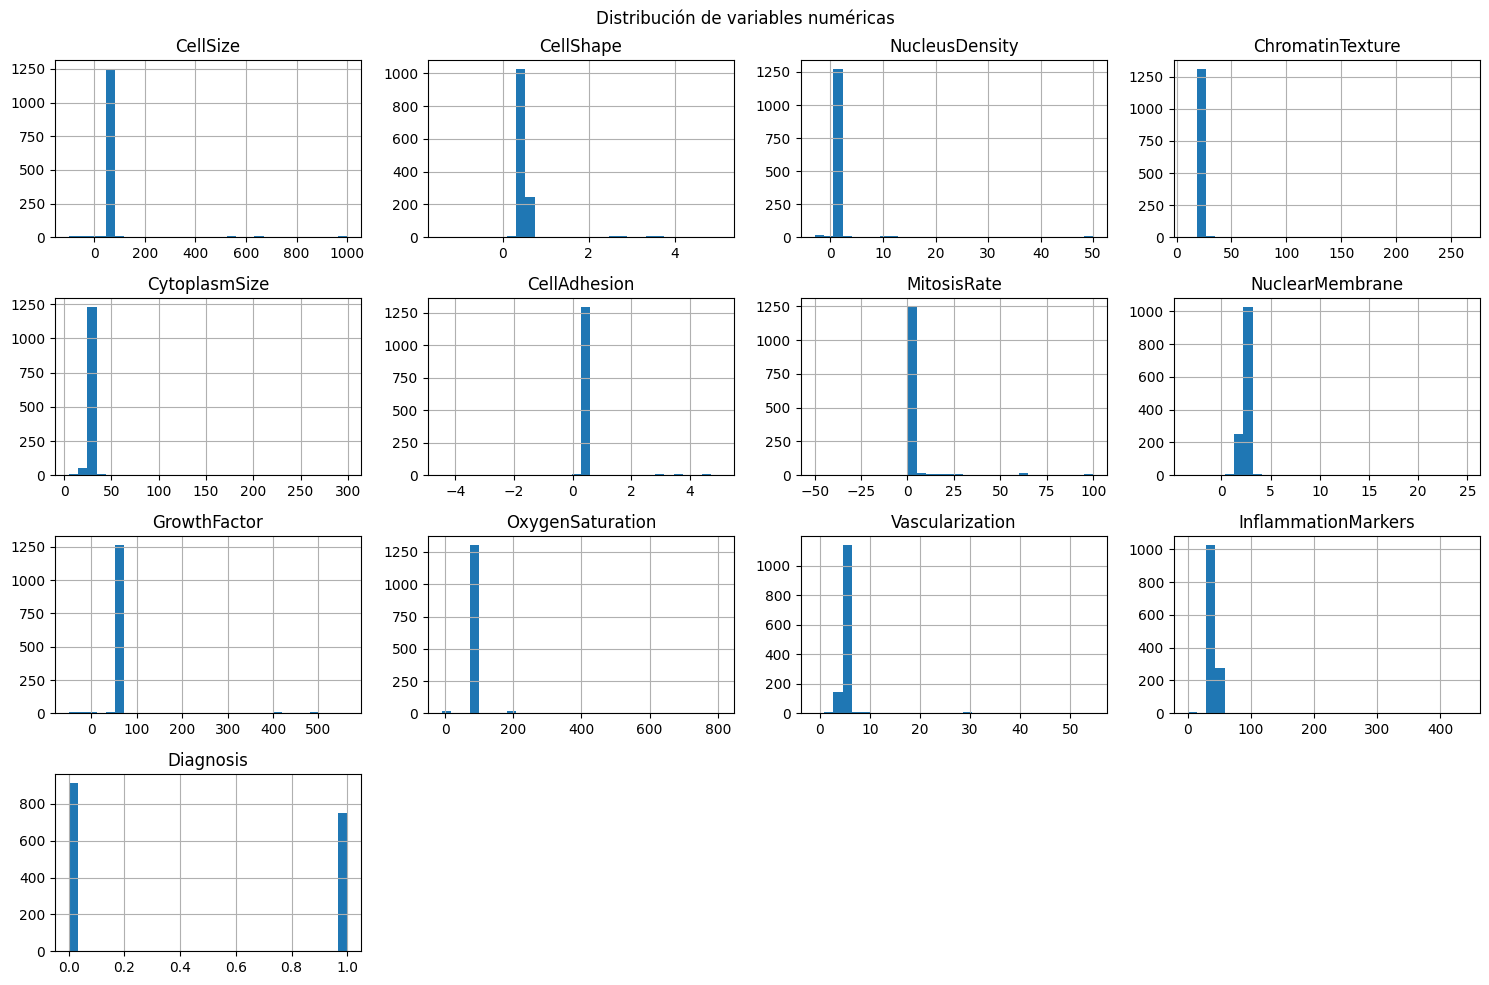

In [380]:
df_num = df_raw.select_dtypes(include='number')

df_num.hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

In [381]:
df_num = df_raw.select_dtypes(include='number').drop(columns=['Diagnosis'], errors='ignore')

for col in df_num.columns:
    data = df_num[col].dropna()  
    
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower) | (data > upper)]

    print(f"  - {col}:")
    print(f"  - Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  - Rango permitido: [{lower:.2f}, {upper:.2f}]")
    print(f"  - Outliers encontrados: {len(outliers)} ({(len(outliers) / len(data)) * 100:.2f}%)")
    print()


  - CellSize:
  - Q1 = 66.57, Q3 = 72.65, IQR = 6.08
  - Rango permitido: [57.45, 81.77]
  - Outliers encontrados: 88 (6.60%)

  - CellShape:
  - Q1 = 0.48, Q3 = 0.52, IQR = 0.04
  - Rango permitido: [0.41, 0.59]
  - Outliers encontrados: 87 (6.46%)

  - NucleusDensity:
  - Q1 = 1.40, Q3 = 1.49, IQR = 0.09
  - Rango permitido: [1.26, 1.62]
  - Outliers encontrados: 115 (8.44%)

  - ChromatinTexture:
  - Q1 = 21.28, Q3 = 22.82, IQR = 1.54
  - Rango permitido: [18.96, 25.14]
  - Outliers encontrados: 65 (4.76%)

  - CytoplasmSize:
  - Q1 = 26.30, Q3 = 30.51, IQR = 4.20
  - Rango permitido: [20.00, 36.81]
  - Outliers encontrados: 61 (4.53%)

  - CellAdhesion:
  - Q1 = 0.46, Q3 = 0.49, IQR = 0.04
  - Rango permitido: [0.40, 0.55]
  - Outliers encontrados: 84 (6.14%)

  - MitosisRate:
  - Q1 = 2.78, Q3 = 3.42, IQR = 0.65
  - Rango permitido: [1.81, 4.39]
  - Outliers encontrados: 109 (8.12%)

  - NuclearMembrane:
  - Q1 = 2.25, Q3 = 2.53, IQR = 0.28
  - Rango permitido: [1.83, 2.95]
  - Ou

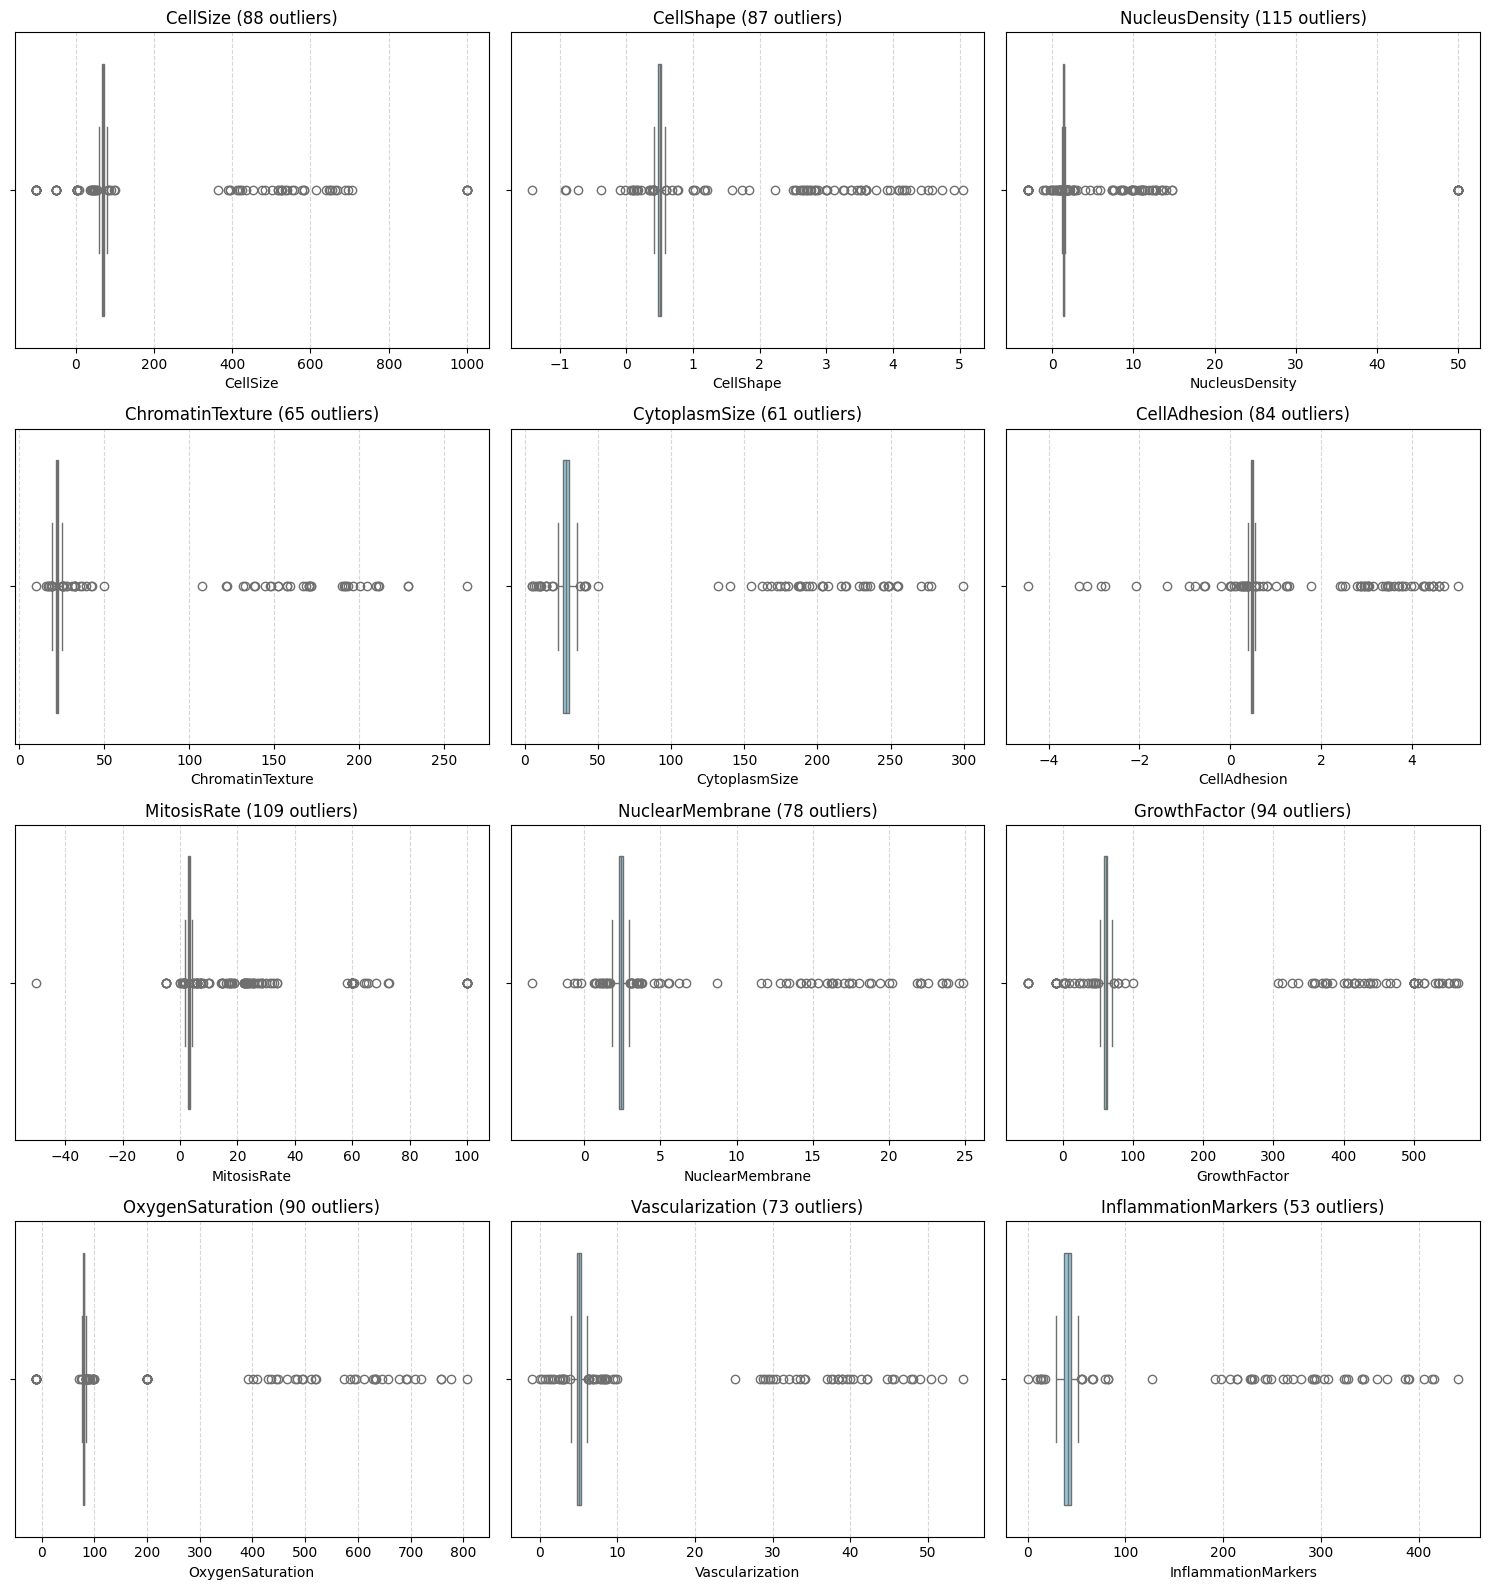

In [382]:
detectar_y_graficar_outliers(df_num)

In [383]:
df_sin_diag = df_num.drop(columns=["Diagnosis"], errors='ignore')

for col in df_sin_diag.columns:
    print(f"{col}: min = {df_raw[col].min()}, max = {df_raw[col].max()}")

CellSize: min = -100.0, max = 1000.0
CellShape: min = -1.4130384579515147, max = 5.048566054248209
NucleusDensity: min = -3.0, max = 50.0
ChromatinTexture: min = 10.0, max = 263.7934254838045
CytoplasmSize: min = 5.0, max = 299.35055914274307
CellAdhesion: min = -4.461754544710936, max = 5.029925063629451
MitosisRate: min = -50.0, max = 100.0
NuclearMembrane: min = -3.4389903256122247, max = 24.8717617385302
GrowthFactor: min = -50.0, max = 563.6226842244846
OxygenSaturation: min = -10.0, max = 807.181057856447
Vascularization: min = -0.9970570932293126, max = 54.512433028480125
InflammationMarkers: min = 0.0, max = 440.9022610930869


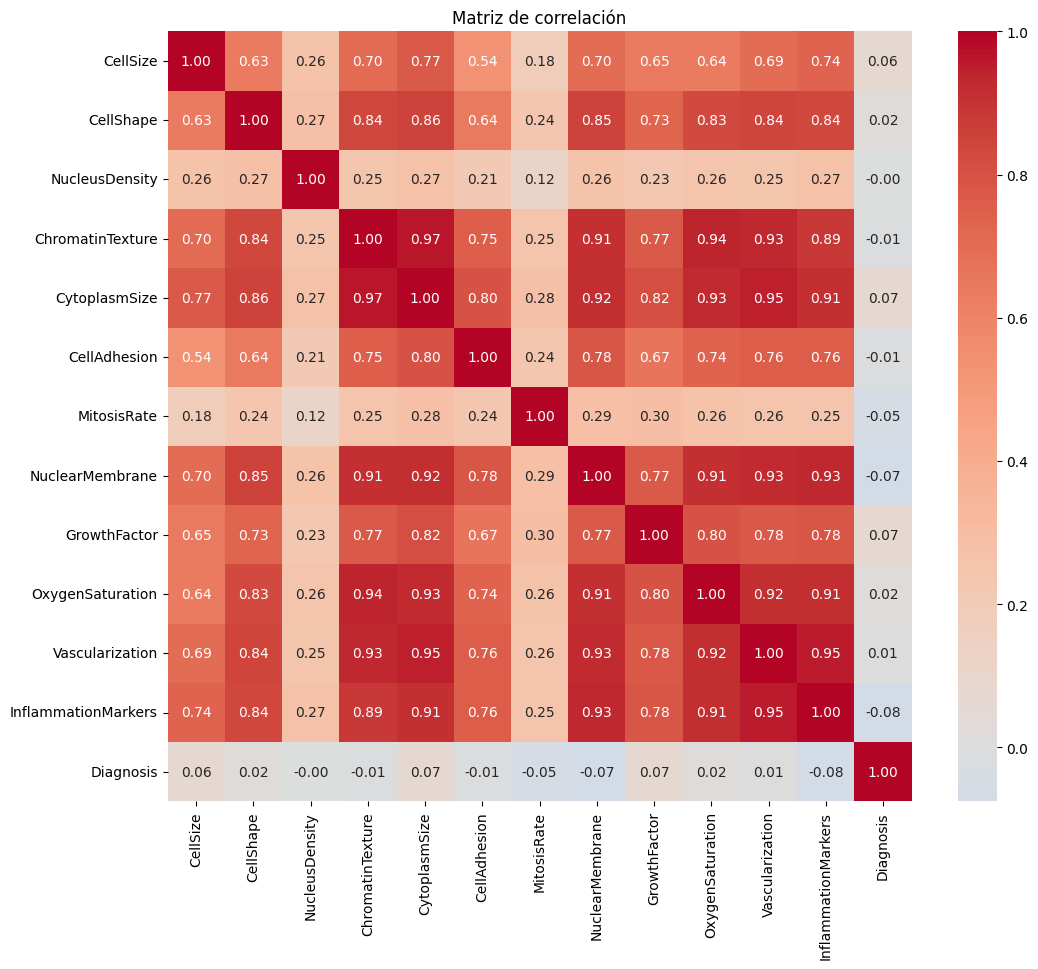

Diagnosis              1.000000
CytoplasmSize          0.070458
GrowthFactor           0.065615
CellSize               0.063615
OxygenSaturation       0.023743
CellShape              0.019966
Vascularization        0.005502
NucleusDensity        -0.001480
ChromatinTexture      -0.005549
CellAdhesion          -0.011341
MitosisRate           -0.046265
NuclearMembrane       -0.069848
InflammationMarkers   -0.075421
Name: Diagnosis, dtype: float64


In [384]:



corr = df_raw.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

print(corr['Diagnosis'].sort_values(ascending=False))


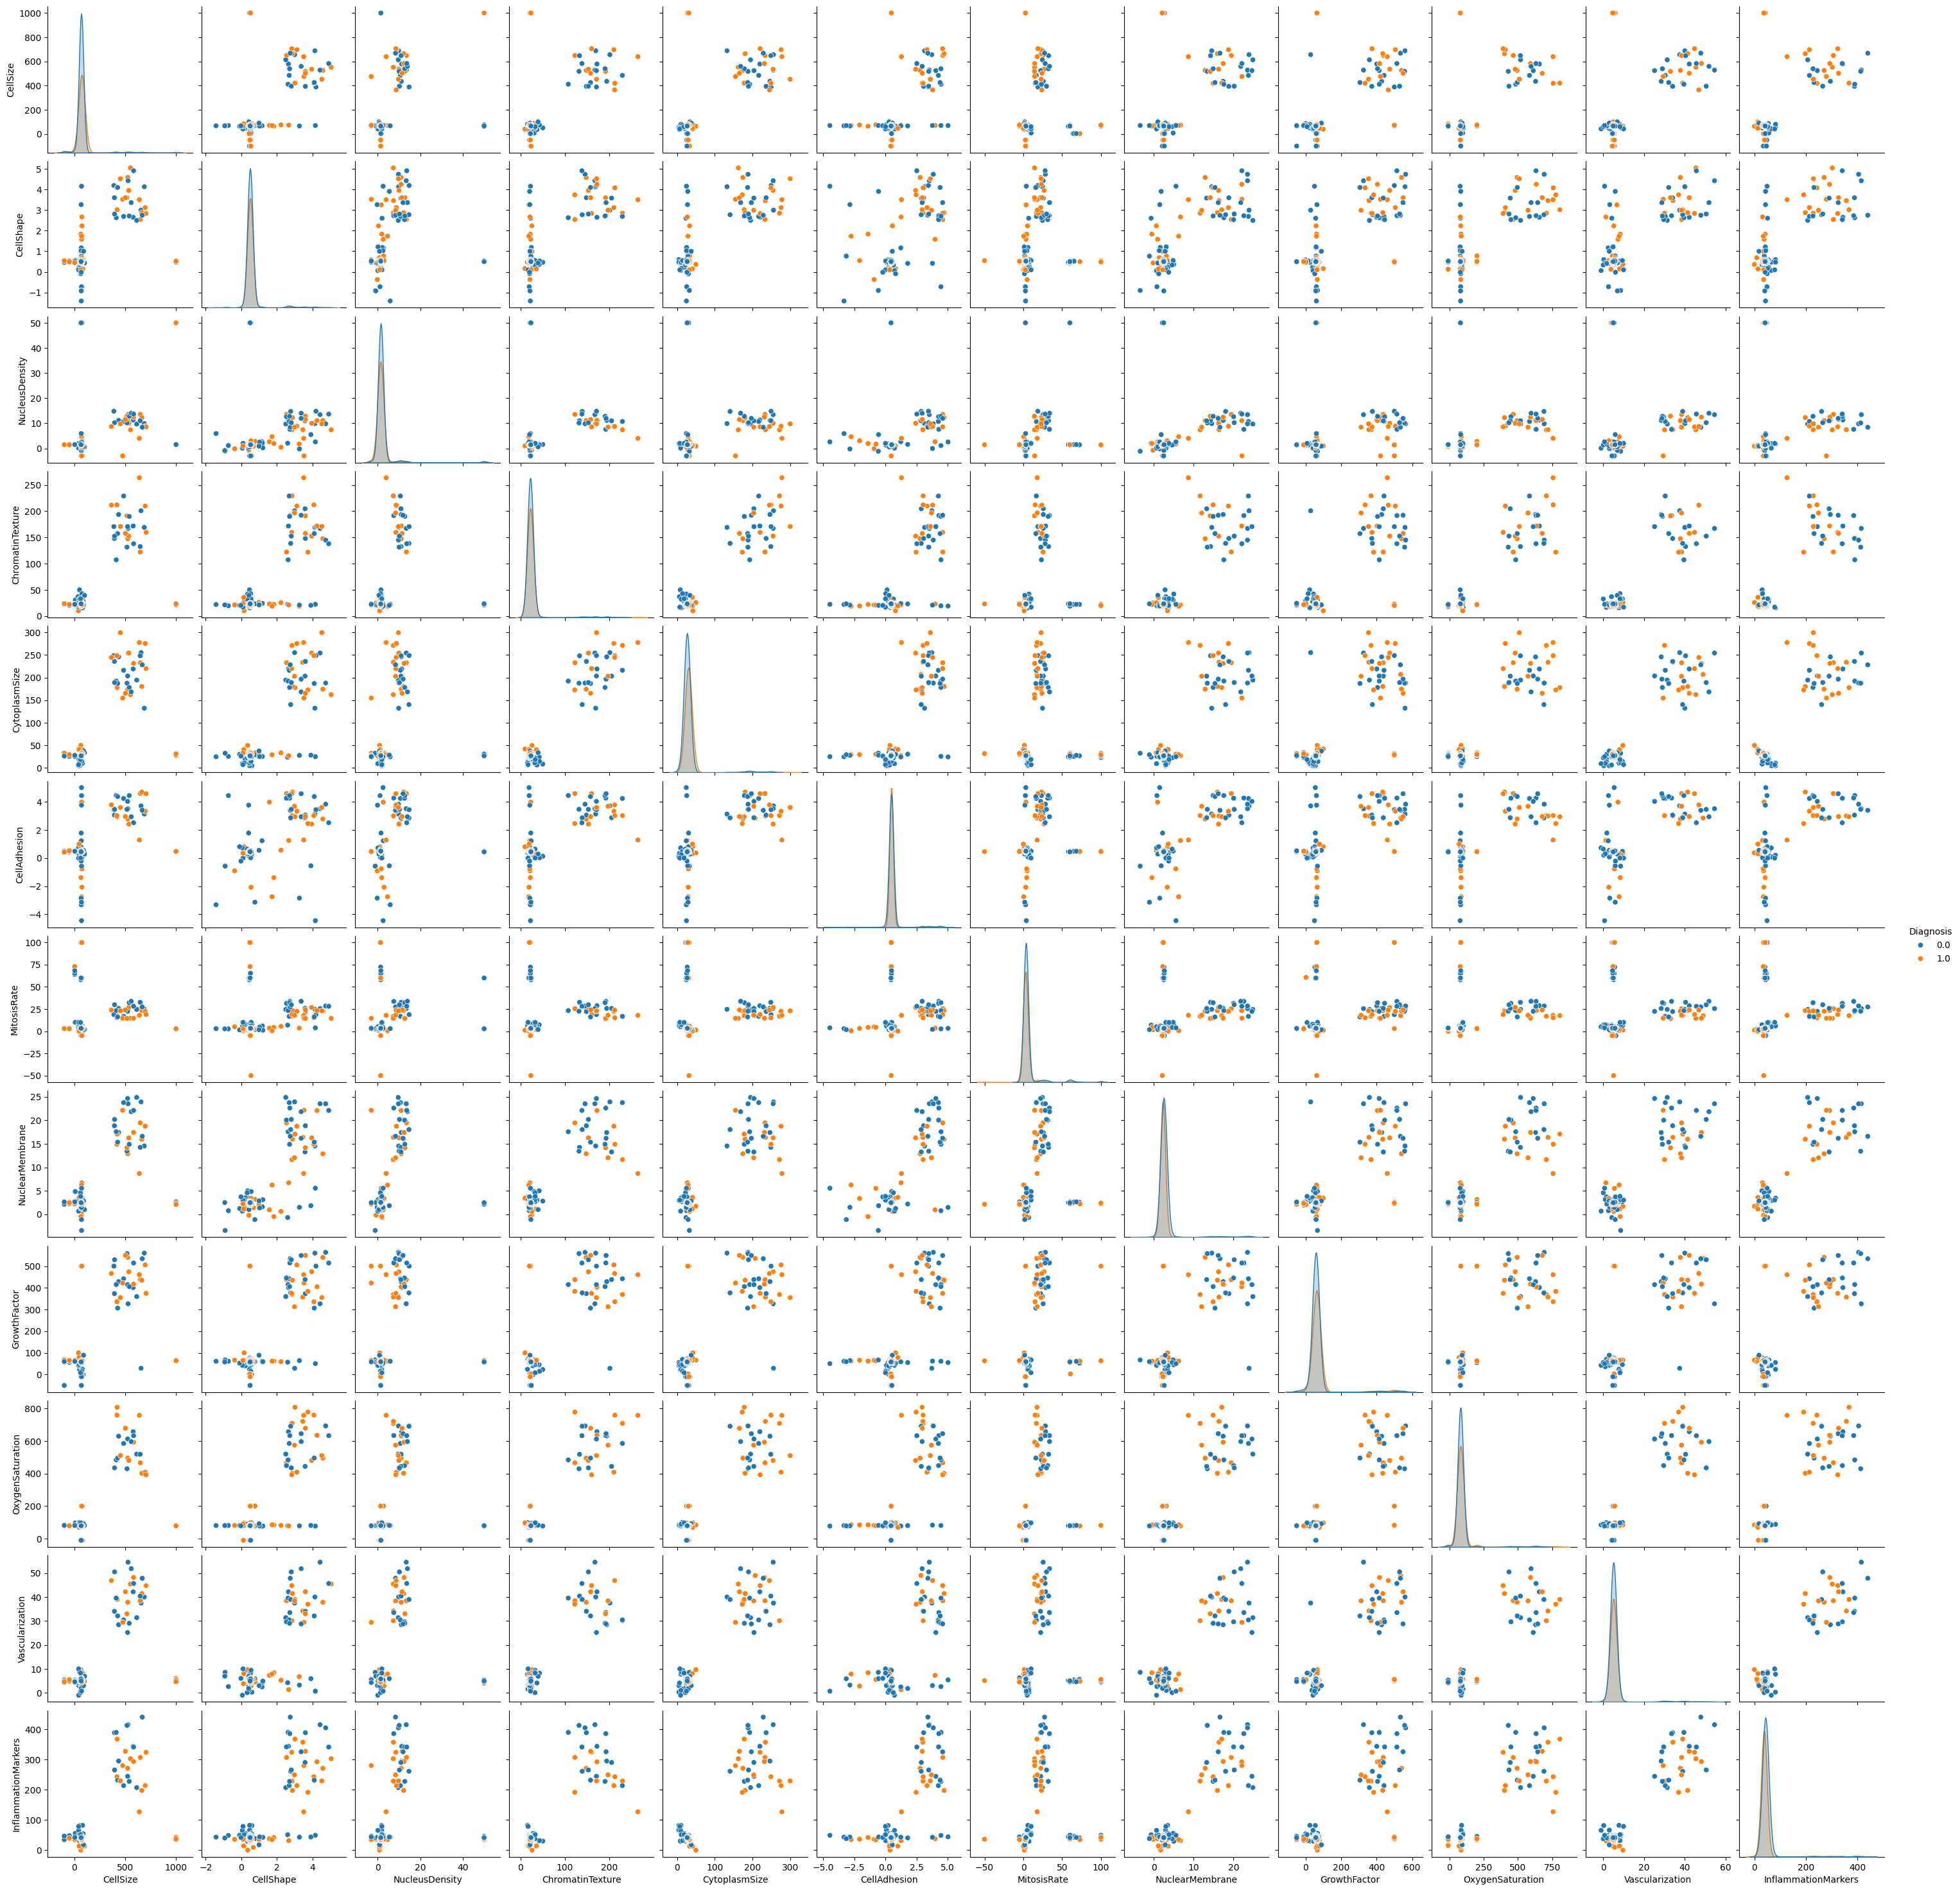

In [385]:


sns.pairplot(df_raw,hue="Diagnosis")
plt.show()

EJERCICIO 1.2


In [386]:
df_procesado = df_raw.copy()
df_procesado["CellType"] = df_procesado["CellType"].fillna("???")
df_procesado=one_hot_encoding(df_procesado, ["CellType","GeneticMutation"]) #sacamos los nans de las categoricas y ya las hicimos numericas


df_procesado.to_csv("data/EJ1/PROCESSED/cell_diagnosis_dev_procesado.csv", index=False)


In [387]:
df_balanced = df_procesado.copy()

train_balanced, val_balanced = divideDataFrame(df_balanced, 0.8)

binary_features=["Diagnosis","CellType_Epthlial","CellType_???","CellType_Mesnchymal","GeneticMutation_Absnt","GeneticMutation_Presnt"]

num_cols = train_balanced.drop(columns=binary_features).select_dtypes(include='number').columns

train_balanced=remove_outliers_iqr(train_balanced, num_cols)

train_balanced=fillNaNs(train_balanced)
val_balanced=fillNaNs(val_balanced)

train_balanced_normalized,val_balanced_normalized,mean_balanced,std_balanced,num_cols=normalizeDataFrame(train_balanced, val_balanced, binary_features)

In [388]:
model=LogisticRegressionL2()

X=train_balanced_normalized.drop(columns=["Diagnosis"])
Y=train_balanced_normalized["Diagnosis"]

model.fit(X,Y)

Accuracy: 0.8889
Precision: 0.8897
Recall: 0.8600
F1 Score: 0.8746
AUC ROC: 0.8637
AUC PR: 0.7913
Matriz de confusión:


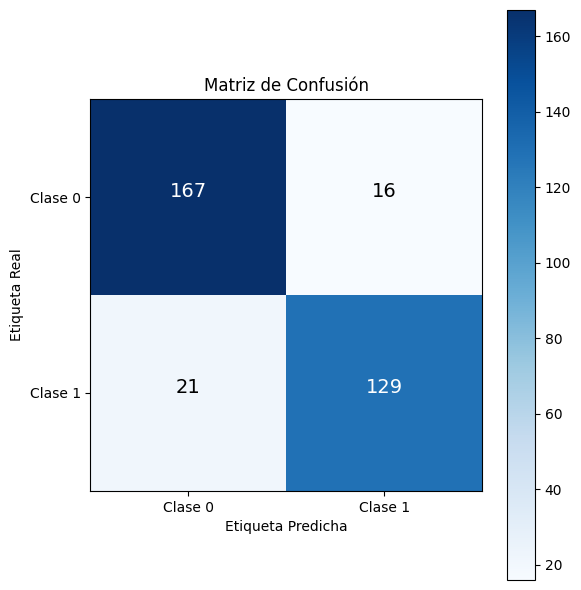

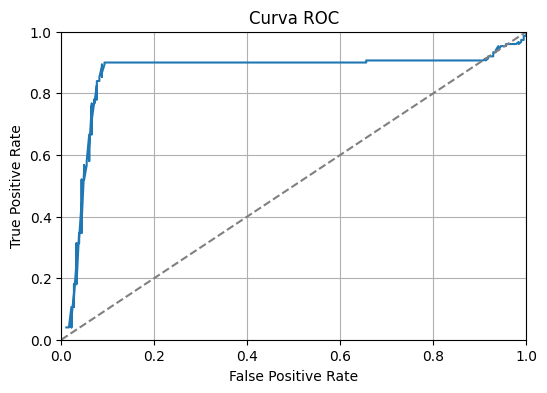

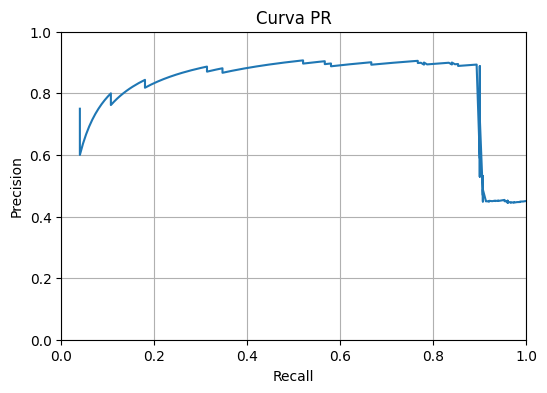

In [389]:
X_val_balanced=val_balanced_normalized.drop(columns=["Diagnosis"])
Ytrue_val_balanced=val_balanced_normalized["Diagnosis"]

val_predY_balanced=model.predict(X_val_balanced)
val_probY_balanced=model.predict_proba(X_val_balanced)

resultados=calcular_metricas(Ytrue_val_balanced, val_predY_balanced,val_probY_balanced)

for metric, value in resultados.items():
    print(f"{metric}: {value:.4f}")
print("Matriz de confusión:")
plot_matrix_confusion(Ytrue_val_balanced, val_predY_balanced)
plot_curvas(Ytrue_val_balanced, val_probY_balanced)


In [390]:
lambdas=np.logspace(-4, 1, 10)
resultados = []


for l in lambdas:
    model = LogisticRegressionL2(lambda_=l) 
    model.fit(X, Y)
    predicciones_val = model.predict(X_val_balanced)
    f1 = fscore(Ytrue_val_balanced, predicciones_val)
    resultados.append((f1, l))

mejor = max(resultados, key=lambda x: x[0])

mejor_f1, mejor_lambda = mejor
print(f"Mejor F1: {mejor_f1:.4f} con λ = {mejor_lambda}")




Mejor F1: 0.8746 con λ = 0.0001


EJERCICIO 1.3


In [391]:
df_test = pd.read_csv("data/EJ1/RAW/cell_diagnosis_test.csv")
df_test["CellType"] = df_test["CellType"].fillna("???")
df_test=one_hot_encoding(df_test, ["CellType","GeneticMutation"]) #sacamos los nans de las categoricas y ya las hicimos numericas

df_test=fillNaNs(df_test)

df_test.to_csv("data/EJ1/PROCESSED/cell_diagnosis_test_procesado.csv", index=False)

In [392]:
x_test = df_test.drop(columns=["Diagnosis"])
x_test[num_cols] = (x_test[num_cols] - mean_balanced) / std_balanced
y_test = df_test["Diagnosis"]

In [393]:
model=LogisticRegressionL2(lambda_=mejor_lambda)

model.fit(X,Y)

Accuracy: 0.8811
Precision: 0.8675
Recall: 0.8675
F1 Score: 0.8675
AUC ROC: 0.8020
AUC PR: 0.6941
Matriz de confusión:


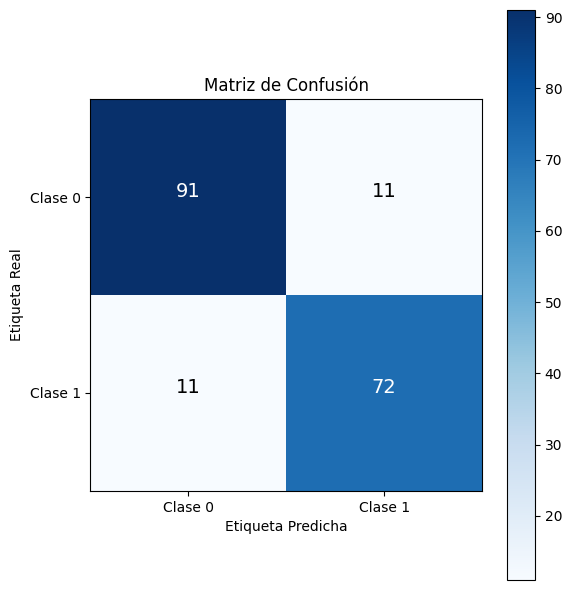

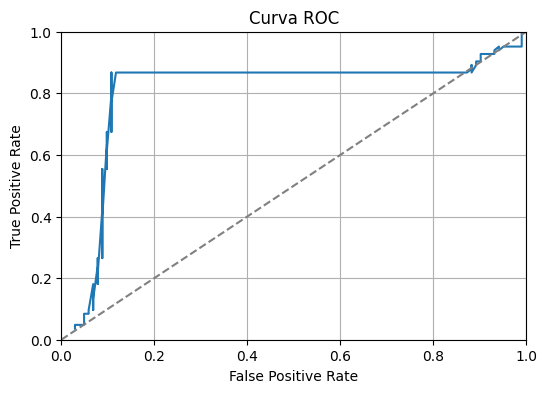

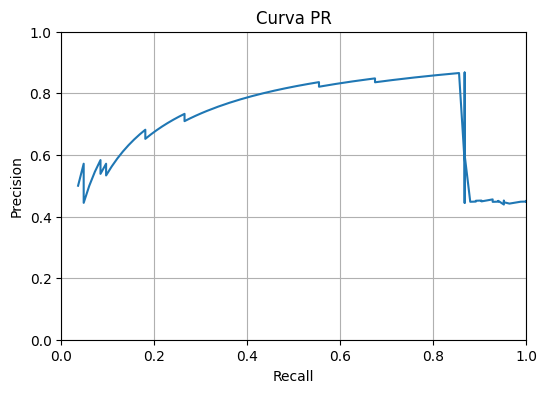

In [394]:
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)
resultados=calcular_metricas(y_test, y_pred,y_prob)
for metric, value in resultados.items():
    print(f"{metric}: {value:.4f}")

print("Matriz de confusión:")
plot_matrix_confusion(y_test, y_pred)

plot_curvas(y_test, y_prob)

EJERCICIO 1.4

In [395]:
df_imbalanced = pd.read_csv("data/EJ1/RAW/cell_diagnosis_dev_imbalanced.csv")

df_imbalanced_processed = df_imbalanced.copy()
df_imbalanced_processed["CellType"] = df_imbalanced_processed["CellType"].fillna("???")
df_imbalanced_processed=one_hot_encoding(df_imbalanced_processed, ["CellType","GeneticMutation"])

df_imbalanced_processed.to_csv("data/EJ1/PROCESSED/cell_diagnosis_dev_imbalanced_procesado.csv", index=False)



In [396]:

df_procesado_imbalanced = df_imbalanced_processed.copy()

train_imbalanced, val_imbalanced = divideDataFrame(df_procesado_imbalanced, 0.8)

binary_features=["Diagnosis","CellType_Epthlial","CellType_???","CellType_Mesnchymal","GeneticMutation_Absnt","GeneticMutation_Presnt"]

num_cols = train_imbalanced.drop(columns=binary_features).select_dtypes(include='number').columns
train_imbalanced=remove_outliers_iqr(train_imbalanced, num_cols)

train_imbalanced=fillNaNs(train_imbalanced)
val_imbalanced=fillNaNs(val_imbalanced)


train_imbalanced_normalized,val_imbalanced_normalized,min_value,max_value,num_cols=minMaxScaleDataFrame(train_imbalanced, val_imbalanced, binary_features)

APLICAR TECNICAS DE REBALANCEO

In [397]:
def procesar_balanceo(dataset, metodo_balanceo):
    balanced = metodo_balanceo(*dataset)
    x = balanced.drop(columns=["Diagnosis"])
    y = balanced["Diagnosis"]
    return x, y

In [398]:

X_imbalanced=train_imbalanced_normalized.drop(columns=["Diagnosis"])
Y_imbalanced=train_imbalanced_normalized["Diagnosis"]

dataset = (X_imbalanced, Y_imbalanced)

x_undersampling, y_undersampling = procesar_balanceo(dataset, src.re_balanced.undersampling)
x_oversampling, y_oversampling = procesar_balanceo(dataset, src.re_balanced.oversampling_duplicacion)
x_oversampling_smote, y_oversampling_smote = procesar_balanceo(dataset, src.re_balanced.oversampling_smote)
x_reWeighting, y_reWeighting = procesar_balanceo(dataset, src.re_balanced.cost_reweighting)


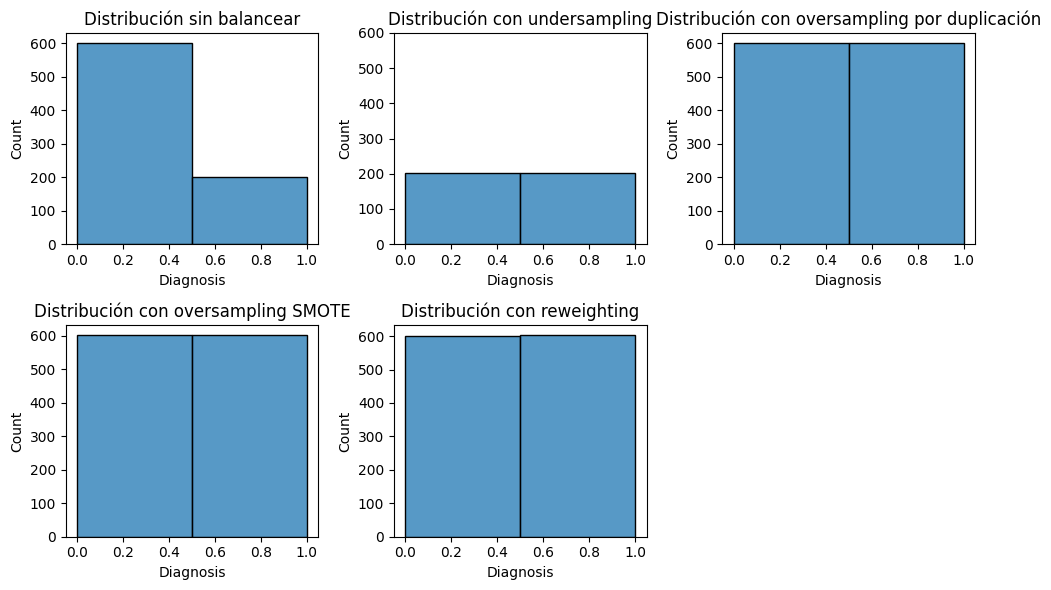

In [399]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
sns.histplot(Y_imbalanced,bins=2, kde=False)
plt.title("Distribución sin balancear")
plt.subplot(2, 3, 2)
sns.histplot(y_undersampling, bins=2, kde=False)
plt.ylim(0, 600)
plt.title("Distribución con undersampling")
plt.subplot(2, 3, 3)
sns.histplot(y_oversampling, bins=2, kde=False)
plt.title("Distribución con oversampling por duplicación")
plt.subplot(2, 3, 4)
sns.histplot(y_oversampling_smote, bins=2, kde=False)
plt.title("Distribución con oversampling SMOTE")
plt.subplot(2, 3, 5)
sns.histplot(y_reWeighting, bins=2, kde=False)
plt.title("Distribución con reweighting")
plt.tight_layout()



BARRIDOS DE LAMBDA

In [400]:
lambdas = np.logspace(-4, 1, 10)

datasets = {
    "sinBalancear": (X_imbalanced, Y_imbalanced),
    "undersampling": (x_undersampling, y_undersampling),
    "oversampling": (x_oversampling, y_oversampling),
    "oversampling_smote": (x_oversampling_smote, y_oversampling_smote),
    "reWeighting": (x_reWeighting, y_reWeighting)
}

resultados = {nombre: [] for nombre in datasets}

X_val = val_imbalanced_normalized.drop(columns=["Diagnosis"])
Y_val = val_imbalanced_normalized["Diagnosis"]

for l in lambdas:
    for nombre, (X_train, Y_train) in datasets.items():
        model = LogisticRegressionL2(lambda_=l)
        model.fit(X_train, Y_train)
        predicciones = model.predict(X_val)
        f1 = fscore(Y_val, predicciones)
        resultados[nombre].append((f1, l))


# Obtener los mejores lambdas
mejores_lambdas = {}
for nombre, resultado in resultados.items():
    mejor_f1, mejor_lambda = max(resultado, key=lambda x: x[0])
    mejores_lambdas[nombre] = mejor_lambda
    print(f"Mejor F1 {nombre}: {mejor_f1:.4f} con λ = {mejor_lambda}")


Mejor F1 sinBalancear: 0.0656 con λ = 0.21544346900318845
Mejor F1 undersampling: 0.7903 con λ = 0.0001
Mejor F1 oversampling: 0.7642 con λ = 0.0001
Mejor F1 oversampling_smote: 0.7541 con λ = 0.0001
Mejor F1 reWeighting: 0.7903 con λ = 0.0001


ENTRENAR Y PREDICTEAR

In [401]:
modelos = {}
predicciones = {}
probabilidades = {}

for nombre in datasets:
    X_train, y_train = datasets[nombre]
    lambda_opt = mejores_lambdas[nombre]
    
    modelo = LogisticRegressionL2(lambda_=lambda_opt)
    modelo.fit(X_train, y_train)
    
    modelos[nombre] = modelo
    predicciones[nombre] = modelo.predict(X_val)
    probabilidades[nombre] = modelo.predict_proba(X_val)


In [402]:
nombres = {
    "sinBalancear": "Sin rebalanceo",
    "undersampling": "Undersampling",
    "oversampling": "Oversampling duplicate",
    "oversampling_smote": "Oversampling SMOTE",
    "reWeighting": "Cost re-weighting"
}

resultados_finales = {
    nombres[nombre]: (predicciones[nombre], probabilidades[nombre])
    for nombre in predicciones
}
tabla_resultados = evaluar_modelos(Y_val, resultados_finales)
print(tabla_resultados)



                        Accuracy  Precision    Recall  F1 Score   AUC ROC  \
Sin rebalanceo          0.766393   0.500000  0.035088  0.065574  0.847312   
Undersampling           0.893443   0.731343  0.859649  0.790323  0.866779   
Oversampling duplicate  0.881148   0.712121  0.824561  0.764228  0.854818   
Oversampling SMOTE      0.877049   0.707692  0.807018  0.754098  0.851581   
Cost re-weighting       0.893443   0.731343  0.859649  0.790323  0.862745   

                          AUC PR  
Sin rebalanceo          0.611563  
Undersampling           0.651483  
Oversampling duplicate  0.640732  
Oversampling SMOTE      0.634781  
Cost re-weighting       0.644758  


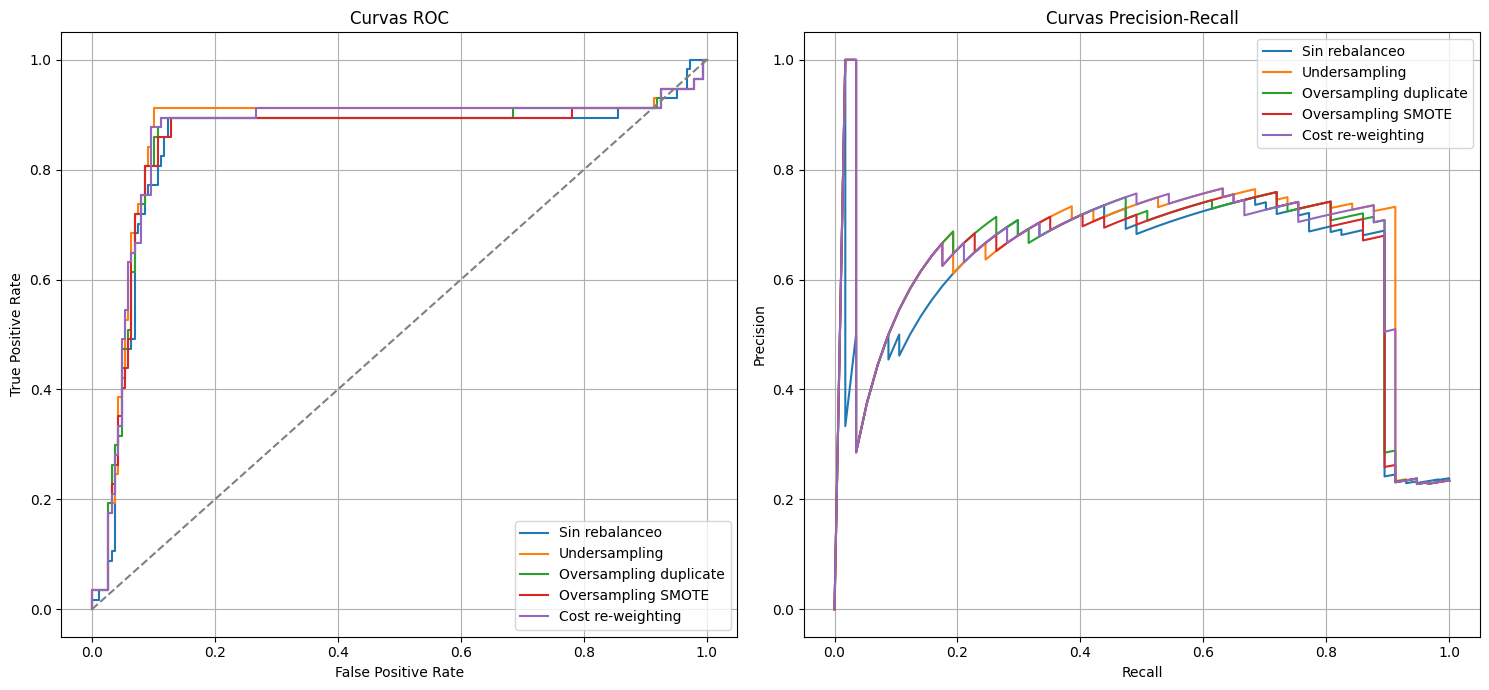

In [403]:
probabilidades_dict = {
    nombres[nombre]: probabilidades[nombre]
    for nombre in probabilidades
}

plot_many_curves(Y_val, probabilidades_dict)


EJERCICIO 1.5

In [404]:
df_imbalanced_test = pd.read_csv("data/EJ1/RAW/cell_diagnosis_test_imbalanced.csv")

df_imbalanced_test_processed = df_imbalanced_test.copy()
df_imbalanced_test_processed["CellType"] = df_imbalanced_test_processed["CellType"].fillna("???")
df_imbalanced_test_processed=one_hot_encoding(df_imbalanced_test_processed, ["CellType","GeneticMutation"])

df_imbalanced_test_processed=fillNaNs(df_imbalanced_test_processed)
df_imbalanced_test_processed.to_csv("data/EJ1/PROCESSED/cell_diagnosis_test_imbalanced_procesado.csv", index=False)


In [405]:
df_imbalanced_dev= pd.read_csv("data/EJ1/PROCESSED/cell_diagnosis_dev_imbalanced_procesado.csv")

binary_features=["Diagnosis","CellType_Epthlial","CellType_???","CellType_Mesnchymal","GeneticMutation_Absnt","GeneticMutation_Presnt"]

num_cols = df_imbalanced_dev.drop(columns=binary_features).select_dtypes(include='number').columns


In [406]:
X=df_imbalanced_dev
X=remove_outliers_iqr(X, num_cols)

X=fillNaNs(X)



min_values = X[num_cols].min()  
max_values = X[num_cols].max()

X[num_cols]=(X[num_cols]-min_values)/(max_values-min_values)

x_train_imbalanced=X.drop(columns=["Diagnosis"])
Y_train_imbalanced=X["Diagnosis"]




In [407]:
test= df_imbalanced_test_processed.copy()

test=fillNaNs(test)
test[num_cols]=(test[num_cols]-min_values)/(max_values-min_values)

x_test_imbalanced=test.drop(columns=["Diagnosis"])
y_test_imbalanced=test["Diagnosis"]

In [408]:
def entrenar_y_predecir(x_train, y_train, lambda_, x_test):
    model = LogisticRegressionL2(lambda_=lambda_)
    model.fit(x_train, y_train)
    predicciones = model.predict(x_test)
    probabilidades = model.predict_proba(x_test)
    return predicciones, probabilidades


In [409]:

# 1. Sin rebalanceo
predicciones_test_sinBalancear, y_prob_sinBalancear = entrenar_y_predecir(x_train_imbalanced, Y_train_imbalanced,
                                                                          mejores_lambdas["sinBalancear"], x_test_imbalanced
                                                                        )

# 2. Undersampling
train_undersampling = src.re_balanced.undersampling(x_train_imbalanced, Y_train_imbalanced)
x_undersampling = train_undersampling.drop(columns=["Diagnosis"])
y_undersampling = train_undersampling["Diagnosis"]

predicciones_test_undersampling, y_prob_undersampling = entrenar_y_predecir(x_undersampling, y_undersampling,
                                                                            mejores_lambdas["undersampling"], x_test_imbalanced
                                                                             )

# 3. Oversampling duplicado
train_oversampling = src.re_balanced.oversampling_duplicacion(x_train_imbalanced, Y_train_imbalanced)
x_oversampling = train_oversampling.drop(columns=["Diagnosis"])
y_oversampling = train_oversampling["Diagnosis"]

predicciones_test_oversampling, y_prob_oversampling = entrenar_y_predecir(x_oversampling, y_oversampling,
                                                                          mejores_lambdas["oversampling"], x_test_imbalanced
                                                                         )

# 4. Oversampling SMOTE
train_oversampling_smote = src.re_balanced.oversampling_smote(x_train_imbalanced, Y_train_imbalanced)
x_oversampling_smote = train_oversampling_smote.drop(columns=["Diagnosis"])
y_oversampling_smote = train_oversampling_smote["Diagnosis"]

predicciones_test_oversampling_smote, y_prob_oversampling_smote = entrenar_y_predecir(x_oversampling_smote, y_oversampling_smote,
                                                                                    mejores_lambdas["oversampling_smote"], x_test_imbalanced
                                                                                    )

# 5. Re-weighting
train_reWeighting = src.re_balanced.cost_reweighting(x_train_imbalanced, Y_train_imbalanced)
x_reWeighting = train_reWeighting.drop(columns=["Diagnosis"])
y_reWeighting = train_reWeighting["Diagnosis"]

predicciones_test_reWeighting, y_prob_reWeighting = entrenar_y_predecir(x_reWeighting, y_reWeighting,
                                                                        mejores_lambdas["reWeighting"], x_test_imbalanced
                                                                        )


In [410]:
probabilidades_test = {
    "sinBalancear": y_prob_sinBalancear,
    "undersampling": y_prob_undersampling,
    "oversampling": y_prob_oversampling,
    "oversampling_smote": y_prob_oversampling_smote,
    "reWeighting": y_prob_reWeighting
}

predicciones_test = {
    "sinBalancear": predicciones_test_sinBalancear,
    "undersampling": predicciones_test_undersampling,
    "oversampling": predicciones_test_oversampling,
    "oversampling_smote": predicciones_test_oversampling_smote,
    "reWeighting": predicciones_test_reWeighting
}


In [411]:
resultados_dict={}
for nombre  in predicciones_test:
    resultados_dict[nombre] = (predicciones_test[nombre], probabilidades_test[nombre])

df_resultados_test = evaluar_modelos(y_test_imbalanced, resultados_dict)
print(df_resultados_test)


                    Accuracy  Precision    Recall  F1 Score   AUC ROC  \
sinBalancear        0.735294   0.250000  0.029412  0.052632  0.765283   
undersampling       0.875000   0.717949  0.823529  0.767123  0.781719   
oversampling        0.882353   0.725000  0.852941  0.783784  0.782151   
oversampling_smote  0.882353   0.725000  0.852941  0.783784  0.781574   
reWeighting         0.882353   0.725000  0.852941  0.783784  0.781430   

                      AUC PR  
sinBalancear        0.498500  
undersampling       0.501735  
oversampling        0.501775  
oversampling_smote  0.501564  
reWeighting         0.502261  


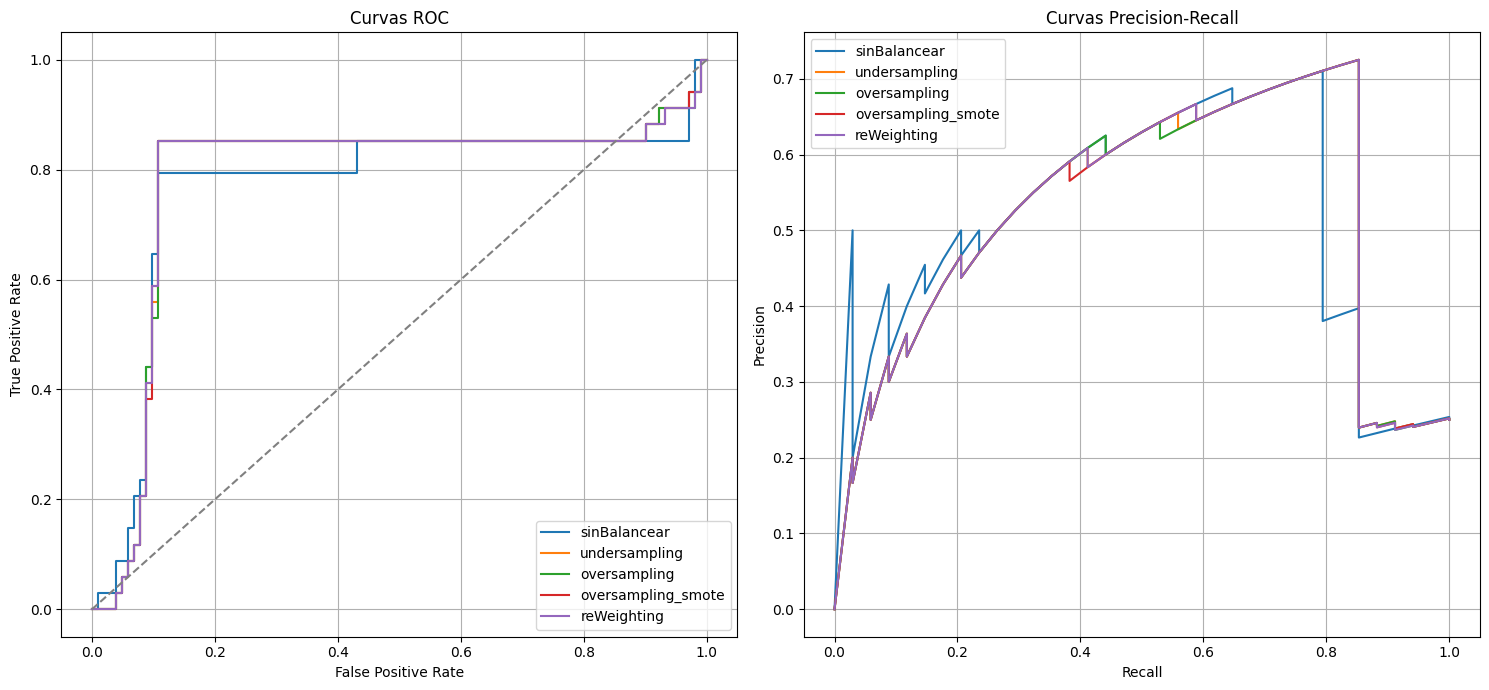

In [412]:
probabilidades_dict = {}
for nombre in probabilidades_test:
    probabilidades_dict[nombre] = probabilidades_test[nombre]



plot_many_curves(y_test_imbalanced, probabilidades_dict)
